# ❤️ Proyecto: Predicción de Enfermedades Cardiovasculares

## 🎯 Objetivos del Proyecto

En este proyecto práctico aprenderás a:

1. **Trabajar con datos médicos reales** del UCI Heart Disease Dataset
2. **Construir un pipeline completo** de Machine Learning
3. **Evaluar modelos de clasificación binaria** con múltiples métricas
4. **Comparar diferentes algoritmos** (SGD vs Random Forest)
5. **Registrar experimentos** con MLflow de forma profesional
6. **Interpretar resultados médicos** con responsabilidad

---

## ❤️ ¿Por qué es importante?

Las **Enfermedades Cardiovasculares (ECV)** son la principal causa de muerte en el mundo:

- 💔 Causan **17.9 millones** de muertes al año
- ⚠️ **90% son prevenibles** con detección temprana
- 🏥 Un diagnóstico temprano puede **salvar vidas**
- 🤖 La IA puede ayudar a **detectar patrones** que salven vidas

---

## 📊 El Dataset: UCI Heart Disease

- **303 pacientes** con datos clínicos
- **14 características** médicas (edad, presión arterial, colesterol, etc.)
- **Variable objetivo**: Presencia de enfermedad cardíaca (0/1)
- **Tipo de problema**: Clasificación binaria

---

## 🎓 Ejercicio Especial: Completa los Comentarios

**🚨 IMPORTANTE**: A lo largo de este notebook verás comentarios como:

```python
# TODO: [Completa aquí] ¿Qué hace esta función?
```

**Tu misión** es completar estos comentarios explicando:
- ¿Qué hace el código?
- ¿Por qué es importante?
- ¿Qué resultado esperamos?

Esto te ayudará a:
- ✅ Entender profundamente cada paso
- ✅ Practicar documentación de código
- ✅ Prepararte para proyectos reales

---

## 🚀 ¡Empecemos!

## ⚙️ Paso 2: Configuración de MLflow

Configuramos el experimento donde registraremos todos nuestros entrenamientos.

## 📚 Paso 3: Importar Librerías

Importamos todas las herramientas necesarias para el proyecto.

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# TODO: [Completa aquí] ¿Qué debes hacer con esta variable email?
email = 'albertoreydelafe@gmail.com'  # ⚠️ CAMBIAR POR TU EMAIL DE DATABRICKS

# Validación
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
else:
    # TODO: [Completa aquí] ¿Para qué sirve set_tracking_uri?
    #Le digo a mlflow donde tiene que guardar los experimentos, aqui en Databricks
    mlflow.set_tracking_uri("databricks")
    
    # TODO: [Completa aquí] ¿Qué hace set_experiment?
    # Crea (o abre si ya existe) la carpeta de experimentos donde se van a agrupar todos mis runs de este notebook
    experiment_name = f"/Users/{email}/5-prediccion-infarto"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 70)
    print("✅ MLflow configurado correctamente")
    print("=" * 70)
    print(f"📊 Experimento: {experiment_name}")
    print(f"❤️  Proyecto: Predicción de Enfermedades Cardiovasculares")
    print("=" * 70)

✅ MLflow configurado correctamente
📊 Experimento: /Users/albertoreydelafe@gmail.com/5-prediccion-infarto
❤️  Proyecto: Predicción de Enfermedades Cardiovasculares


In [0]:
%pip install seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: [Completa aquí] ¿Para qué sirve train_test_split?
from sklearn.model_selection import train_test_split

# TODO: [Completa aquí] ¿Qué es un Pipeline en sklearn?
from sklearn.pipeline import Pipeline

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# TODO: [Completa aquí] ¿Qué modelos vamos a usar?
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

# TODO: [Completa aquí] ¿Para qué sirve cross_val_score?
from sklearn.model_selection import cross_val_score, cross_val_predict

# TODO: [Completa aquí] ¿Qué métricas usaremos y por qué?
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_auc_score,
    accuracy_score,
    classification_report,
    roc_curve
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## ❤️ Contexto del Proyecto

### El Problema

En este proyecto trabajaremos con el **UCI Heart Disease Dataset**, uno de los datasets más importantes en medicina predictiva. 

### 📊 Datos Clave sobre ECV

- 💔 **Principal causa de muerte** a nivel mundial
- 📈 **17.9 millones** de muertes anuales
- ⚠️ **90% son prevenibles** con detección temprana
- 🎯 **Diagnóstico temprano** = vidas salvadas
- 🤖 **IA** puede detectar patrones imperceptibles para humanos

### 🎯 Nuestro Objetivo

Construir un modelo de Machine Learning que pueda **predecir la presencia de enfermedad cardiovascular** basándose en características clínicas del paciente.

### ⚕️ Responsabilidad Ética

> ⚠️ **IMPORTANTE**: Este es un proyecto educativo. Los modelos médicos reales requieren:
> - Validación clínica exhaustiva
> - Aprobación regulatoria
> - Supervisión médica profesional
> - Consideraciones éticas y legales

Nuestro objetivo es aprender las técnicas, no reemplazar el criterio médico.

## 📚 Fundamentos: Clasificación Binaria

### 🎯 ¿Qué es Clasificación Binaria?

Un problema donde el modelo debe elegir entre **dos clases**:
- ✅ Clase Positiva (1): Tiene enfermedad cardíaca
- ❌ Clase Negativa (0): No tiene enfermedad cardíaca

---

### 🔄 Pipeline de Entrenamiento

```
1. Preparación de Datos
   ↓
2. Selección del Modelo
   ↓
3. Entrenamiento
   ↓
4. Ajuste de Hiperparámetros
   ↓
5. Evaluación
```

---

### 📊 Métricas de Evaluación

#### 1. **Matriz de Confusión**

|                    | Predicción: No (0) | Predicción: Sí (1) |
|--------------------|--------------------|--------------------|
| **Real: No (0)**   | TN (Verdadero Neg) | FP (Falso Positivo)|
| **Real: Sí (1)**   | FN (Falso Negativo)| TP (Verdadero Pos) |

#### 2. **Precision (Precisión)**
```
Precision = TP / (TP + FP)
```
- "De los que predije como enfermos, ¿cuántos realmente lo están?"
- **Importante cuando**: Los falsos positivos son costosos

#### 3. **Recall (Sensibilidad)**
```
Recall = TP / (TP + FN)
```
- "De todos los enfermos reales, ¿cuántos detecté?"
- **Importante cuando**: No podemos perder ningún caso positivo (medicina)

#### 4. **F1-Score**
```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```
- Balance entre Precision y Recall
- Útil cuando las clases están desbalanceadas

#### 5. **ROC-AUC**
- Curva ROC: Representa el trade-off entre True Positive Rate y False Positive Rate
- AUC: Área bajo la curva (0.5 = aleatorio, 1.0 = perfecto)

#### 6. **Validación Cruzada**
- Divide datos en K partes (folds)
- Entrena K veces, cada vez con un fold diferente como test
- Promedia resultados para obtener estimación robusta

---

### 🎯 ¿Qué métrica usar?

| Situación | Métrica Principal |
|-----------|-------------------|
| Clases balanceadas | Accuracy |
| No perder positivos (medicina) | **Recall** ⭐ |
| Evitar falsos positivos | Precision |
| Balance general | F1-Score |
| Comparar modelos | ROC-AUC |

**En medicina, típicamente priorizamos Recall** porque es mejor detectar un caso falso positivo que perder un verdadero positivo.

## 📁 Paso 4: Cargar y Explorar los Datos

Cargamos el dataset y realizamos un análisis exploratorio inicial.

In [0]:
# TODO: Carga los datos y explica qué contiene el archivo.
data = pd.read_csv('/Workspace/Users/albertoreydelafe@gmail.com/clase_semana0_mlops_mlflow/data/raw/heart.csv')

# TODO: Muestra número de filas, columnas y variable objetivo.
print(data.shape)
print(data.columns)
print(data.target)

(303, 14)
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')
0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64


In [0]:
# TODO: Muestra las primeras filas con head().
data.head()
# TODO: Explica por qué esta inspección es útil antes de modelar.
#Esta inspeccion es útil porque nos enseña la estructura de las primeras 5 filas y asi vemos las columnas,los datos,las columnas y nos da una idea general de como se ven los datos




,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Male,asymptomatic,145.0,233.0,True,normal,150,No,2.3,upsloping,0,1,1
1,37,Male,non-anginal pain,NaN,250.0,False,having ST-T wave abnormality,187,No,3.5,upsloping,0,2,1
2,41,Female,atypical angina,NaN,204.0,False,normal,172,No,1.4,downsloping,0,2,1
3,56,Male,atypical angina,120.0,236.0,False,having ST-T wave abnormality,178,No,0.8,downsloping,0,2,1
4,57,Female,typical angina,120.0,NaN,False,having ST-T wave abnormality,163,Yes,0.6,downsloping,0,2,1


### 📋 Diccionario de Datos

Cada columna representa una característica médica importante:

#### 👤 Datos Demográficos
1. **age**: Edad del paciente en años
2. **sex**: Sexo (1 = masculino, 0 = femenino)

#### 💊 Síntomas y Diagnóstico
3. **cp**: Tipo de dolor de pecho (Chest Pain)
   - 0: Angina típica
   - 1: Angina atípica
   - 2: Dolor no anginoso
   - 3: Asintomático

4. **exang**: Angina inducida por ejercicio (1 = sí, 0 = no)

#### 🩺 Mediciones Clínicas
5. **trestbps**: Presión arterial en reposo (mm Hg)
6. **chol**: Colesterol sérico (mg/dl)
7. **fbs**: Azúcar en sangre en ayunas > 120 mg/dl (1 = verdadero, 0 = falso)
8. **thalach**: Frecuencia cardíaca máxima alcanzada

#### 📊 Resultados de Pruebas
9. **restecg**: Resultados electrocardiográficos en reposo
   - 0: Normal
   - 1: Anormalidad de onda ST-T
   - 2: Hipertrofia ventricular izquierda

10. **oldpeak**: Depresión del segmento ST inducida por ejercicio

11. **slope**: Pendiente del segmento ST durante ejercicio
    - 0: Ascendente
    - 1: Plano
    - 2: Descendente

12. **ca**: Número de vasos principales coloreados por fluoroscopia (0-3)

13. **thal**: Resultados de prueba de talasemia
    - 1: Normal
    - 2: Defecto fijo
    - 3: Defecto reversible

#### 🎯 Variable Objetivo
14. **target**: Presencia de enfermedad cardíaca
    - 0: No enfermedad
    - 1: Enfermedad presente

---

**💡 Tip**: En medicina, cada una de estas características tiene significado clínico. Un buen data scientist debe entender el dominio del problema.

In [0]:
# TODO: Usa info() para revisar tipos de datos y valores nulos.
data.info()

# TODO: Anota qué columnas parecen categóricas y cuáles numéricas.
#Las columnas categoricas son aquellas compuestas por texto,es decir las columnas de tipo object.
#Las columnas numericas son aquellas compuestas por numeros,es decir las columnas de tipo int64,float64.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  258 non-null    float64
 4   chol      273 non-null    float64
 5   fbs       303 non-null    bool   
 6   restecg   303 non-null    object 
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    object 
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    object 
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: bool(1), float64(3), int64(5), object(5)
memory usage: 31.2+ KB


In [0]:
# TODO: Usa describe() para obtener estadísticas descriptivas.
data.describe()     #describe() nos da un resumen estadistico de las columnas numericas,no incluye las columnas categoricas.Si queremos que las incluya,hacemos un 
#describe(include='all')

# TODO: Escribe observaciones sobre valores atípicos y posibles valores perdidos.

#En un primer vistazo no localizo valores atipicos ,pero vemos que hay valores perdidos en trestbps y chol,ya que el count de todas las demas columnas es 303(303 filas con sus respectivos valores) mientras que el de estas es de 258 y 273 respectivamente





,age,trestbps,chol,thalach,oldpeak,ca,thal,target
count,303.000000,258.000000,273.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.465116,245.871795,149.646865,1.039604,0.729373,2.313531,0.544554
std,9.082101,16.914317,52.528792,22.905161,1.161075,1.022606,0.612277,0.498835
min,29.000000,94.000000,131.000000,71.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,209.000000,133.500000,0.000000,0.000000,2.000000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000,0.000000,2.000000,1.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000,3.000000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,4.000000,3.000000,1.000000


### 💡 Observaciones Clave

**TODO: [Completa aquí] Basándote en las estadísticas, ¿qué observaciones puedes hacer sobre:**
- La edad media de los pacientes:

La edad media de los pacientes es de 54 años,lo que tiene sentido al ser datos recogidos de cardiopatías.Lo sorprendente sería que esta media fuese más baja,porque estas dolencias suelen afectar más a la población de mayor edad

- El rango de valores de cada característica

Vemos que los rangos de valores tienen todos sentido,estando dentro de valores normales

- La presencia de valores nulos:

Hay valores nulos en dos columnas: trestbps (le faltan 45 de 303) y chol (le faltan 30 de 303). El resto de columnas numéricas no tiene huecos. Esto habrá que arreglarlo

- Características que pueden necesitar normalización

Casi todas las columnas numéricas tienen escalas distintas (age: 29-77, trestbps: 94-200, chol: 131-564, thalach: 71-202, oldpeak: 0-6.2), así que conviene normalizarlas con StandardScaler antes de entrenar, para que ninguna domine por tener números más grandes.


In [0]:
# TODO: Analiza la distribución de la variable objetivo.
target_counts = data['target'].value_counts()
print(target_counts)

# TODO: Calcula proporciones por clase.
target_props = data['target'].value_counts(normalize=True)  # lo mismo pero en porcentaje
print(target_props)

# TODO: Decide si el dataset está balanceado y explica por qué importa.

#El dataset esta bastante balanceado,porque hay un 54.4% de enfermos y un 45.5% de personas sanas,una diferencia pequeña que hace que no domine una clase sobre la otra.
#Esto es importante porque si estuviese muy desbalanceado el modelo podria aprender a predecir simplemente atribuyendo a la clase más mayoritaria y no aprender a predecir correctamente.Al estar balanceado el accurracy es una metrica razonable


target
1    165
0    138
Name: count, dtype: int64
target
1    0.544554
0    0.455446
Name: proportion, dtype: float64


### 🔍 Análisis Exploratorio Visual

Visualicemos las relaciones entre características para entender mejor los datos.

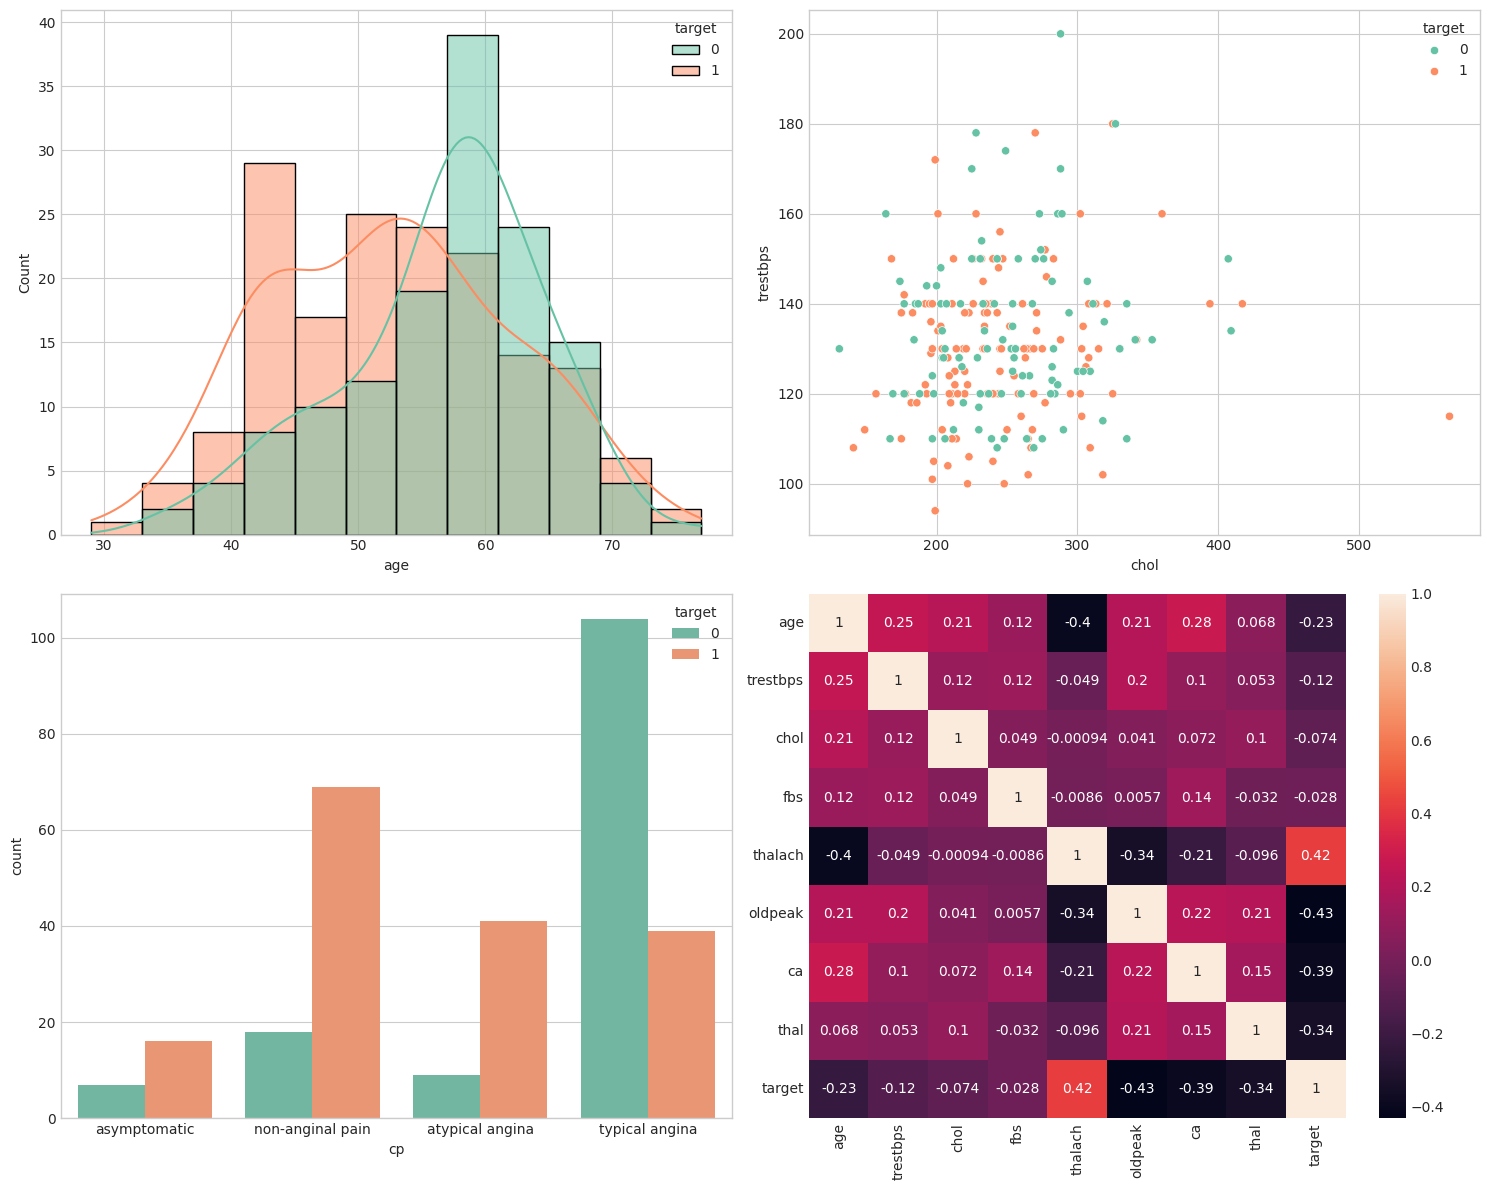

In [0]:
# TODO: Crea visualizaciones para explorar patrones del dataset.
# Ideas:
# - Distribución de edad por diagnóstico
# - Colesterol vs presión arterial coloreado por target
# - Tipo de dolor de pecho vs diagnóstico
# - Matriz de correlación

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Distribucion de la edad, separado por si tiene la enfermedad o no
sns.histplot(data=data, x='age', hue='target', kde=True, ax=axes[0, 0])

# Colesterol vs presion arterial, coloreado por diagnostico
sns.scatterplot(data=data, x='chol', y='trestbps', hue='target', ax=axes[0, 1])

# Cuantos pacientes de cada tipo de dolor de pecho tienen o no la enfermedad
sns.countplot(data=data, x='cp', hue='target', ax=axes[1, 0])

# Relacion entre las columnas numericas
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, ax=axes[1, 1])

plt.tight_layout()
plt.show()

# TODO: Escribe qué patrones observas en los gráficos.
#-Edad:
#De forma sorprendente,las personas con menor edad resultan muy afectada por ka enfermedad,mientras que en los grupos mayores la prediccion deja ver que hay menor numero de afectados en estas edades.Esto se puede ver tambien en el gráfico de #correlaciones,donde edad y target tienen una correlacion de -0.23,por lo que si edad aumenta,la posibilidad de que tengan enfermedad disminuye.Es contraintuitivo.

#-Colesterol vs presion arterial:
# A primera vista no distingo patrones en este gráfico ,y parece ser que no hay una relacion muy estrecha entre estas variables,ni tampoco son un indicativo directo de tener la enfermedad.Lo corroboramos con la gráfica de #correlaciones,que muestra que tienen una correlacion de -0.07 y -0.12 con target.

#Tipo de dolor de pecho: 
# aqui si hay un patron muy claro. Los pacientes con "typical angina" son mayoritariamente sanos (target=0), mientras que el resto de tipos de dolor (sobre todo"non-anginal pain") tienen muchos mas casos de enfermedad (target=1). Es la variable categorica
# que mas distingue entre clases de las que hemos mirado.

#Correlacion con target: 
#la relacion mas fuerte es con thalach (0.42, positiva): a mayor frecuencia cardiaca maxima alcanzada, mas probabilidad de enfermedad. Las mas fuertes en negativo son oldpeak (-0.43), ca (-0.39) y thal (-0.34).


## 🔀 Paso 5: Dividir los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: Divide los datos en train y test.
# Pistas:
# - Usa train_test_split
# - Define test_size
# - Usa random_state para reproducibilidad
X = data.drop(columns='target')
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# TODO: Comprueba el tamaño de cada conjunto.
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())


(242, 13) (61, 13)
target
1    132
0    110
Name: count, dtype: int64
target
1    33
0    28
Name: count, dtype: int64


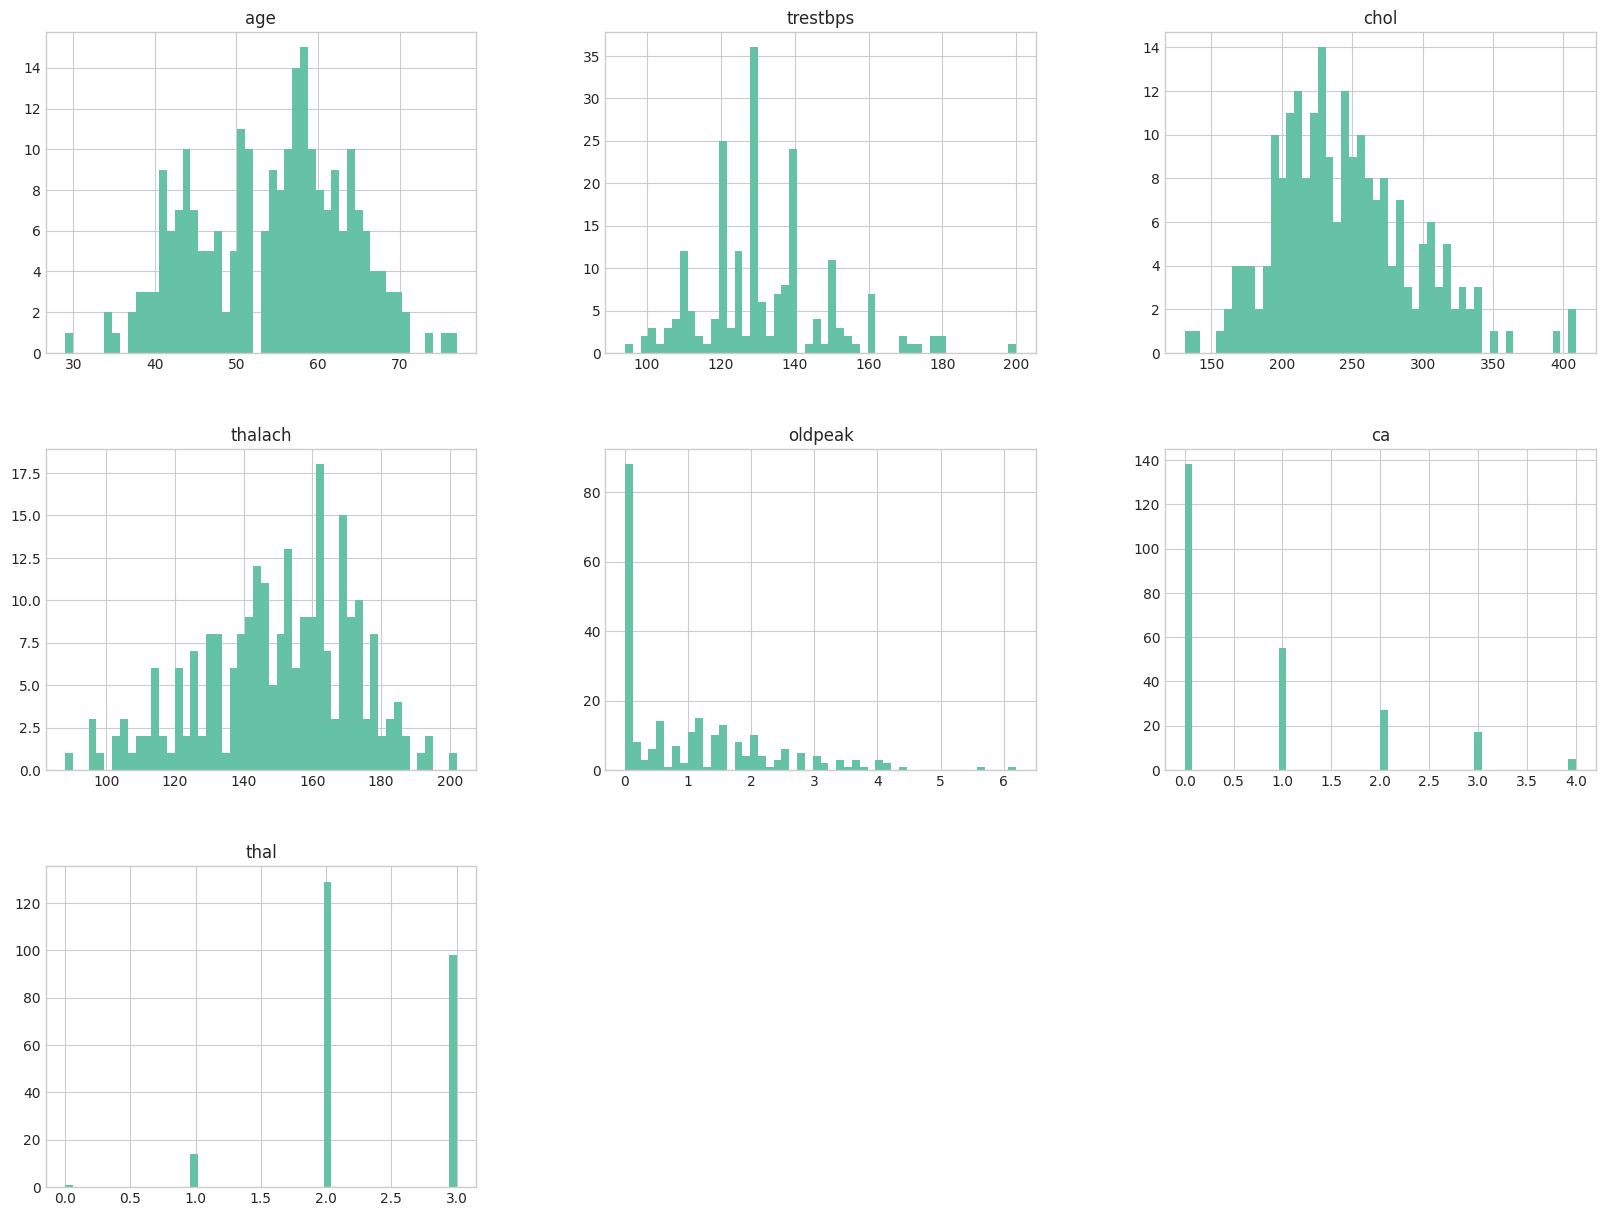

In [0]:
# TODO: Genera histogramas del conjunto de entrenamiento.
X_train.hist(bins=50, figsize=(20, 15))
plt.show()

# TODO: Identifica características con escalas o distribuciones muy diferentes.
#Chol tiene el rango mas amplio de todas (126 a mas de 400).
#Oldpeak tiene el rango mas pequeño (0 a 6.2 aprox), casi todo concentrado entre 0 y 2.
#La diferencia de escala entre chol y oldpeak es enorme


### 📏 Observación Importante: Escalas Diferentes

**TODO: [Completa aquí] ¿Por qué es un problema que las características tengan escalas diferentes?**

Porque hay columnas con numeros mucho mas grandes que otras (chol llega a 400, oldpeak solo a 6). Si no arreglamos esto, el modelo puede pensar que chol importa mas solo por tener numeros mas grandes, no porque sea mas util para predecir.

Revisa columnas como `age`, `trestbps`, `chol`, `thalach` y `oldpeak`.

**TODO: [Completa aquí] ¿Qué transformación aplicarías para que las variables numéricas sean comparables?**

Usaria un StandardScaler, que pone todas las columnas en la misma escala (todas con media 0 mas o menos).

**TODO: [Completa aquí] ¿Por qué esto ayuda a algunos modelos de Machine Learning?**

Porque hay modelos que se fijan en el tamaño de los numeros para decidir lo importante que es cada columna. Si todas estan en la misma escala, ninguna columna pesa mas que otra solo por casualidad


## 🔧 Paso 6: Construir el Pipeline de Preprocesamiento

Crearemos un pipeline que prepare los datos automáticamente.

In [0]:
# TODO: Clasifica las columnas en categóricas y numéricas.
cat_attr = ['sex', 'cp', 'restecg', 'exang', 'slope']
num_attr = ['age', 'trestbps', 'chol', 'fbs', 'thalach', 'oldpeak', 'ca', 'thal']

# TODO: Crea un pipeline para variables numéricas.
# Pistas:
# - SimpleImputer para valores nulos
# - StandardScaler para estandarizar
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # relleno los huecos con la mediana de cada columna
    ('scaler', StandardScaler()),   # pongo todas las columnas en la misma escala
])

# TODO: Crea un ColumnTransformer que combine numéricas y categóricas.
# Pista: usa OneHotEncoder para variables categóricas.
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attr),  # aplico el pipeline numerico (relleno + escalado) a las columnas numericas
    ('cat', OneHotEncoder(), cat_attr),  # convierto las columnas categoricas en columnas de 0 y 1
])

# TODO: Explica por qué usamos One-Hot Encoding para categóricas.
#Los modelos solo entienden numeros, pero si a cp le pongo numeros tipo 0,1,2,3, el modelo podria pensar que hay un orden entre ellos (que #3 es "mas" que 0), y en realidad son solo etiquetas distintas, sin relacion entre si.
# One-Hot Encoding soluciona esto creando una columna nueva por cada categoria, con un 1 si el paciente tiene esa categoria y un 0 si no. Asi el modelo no se inventa un orden que no existe.


## 🎯 Paso 7: Preparar X e y

Separamos características (X) de la variable objetivo (y).

In [0]:
# TODO: Separa características (X) y target (y) del conjunto de entrenamiento.
# x_train = ...
# y_train = ...
# Ya hecho en la celda 18: reutilizo x_train e y_train
# TODO: Comprueba las dimensiones resultantes.
print(X_train.shape,y_train.shape)


(242, 13) (242,)


In [0]:
# TODO: Aplica el pipeline al conjunto de entrenamiento.
x_train_pr = full_pipeline.fit_transform(X_train)

# TODO: Explica la diferencia entre fit_transform y transform.

# fit_transform hace dos cosas a la vez: "fit" (aprende los parametros necesarios a partir de x_train: la mediana para rellenar huecos, la media y desviacion para escalar, y las categorias que existen para el One-Hot) y "transform" (aplica esa transformacion ya aprendida).
# transform (solo) no aprende nada nuevo, solo aplica los parametros que ya se aprendieron antes. 

# TODO: Comprueba cómo cambia el número de columnas.
print(X_train.shape)
print(x_train_pr.shape)


2026/10/02 12:37:58 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 12:37:58 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ede3ee4a8fa44b5196458b1f2455c3a5', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/02 12:37:58 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 12:37:58 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-c463eae0-f43f.cloud.databricks.com/ml/experiments/12157694223

(242, 13)
(242, 22)


## 🤖 Paso 8: Entrenamiento y Evaluación de Modelos

Entrenaremos dos modelos y compararemos sus resultados usando MLflow.

### 🔵 Modelo 1: SGD Classifier (Baseline)

**TODO: [Completa aquí] ¿Qué es SGD (Stochastic Gradient Descent) y cómo funciona?**
#hecho con IA
SGD (Descenso de Gradiente Estocástico) es una forma de entrenar un modelo ajustando sus parámetros poco a poco, mirando los datos de uno en uno (o en grupos pequeños), en vez de mirarlos todos a la vez. En cada paso, calcula hacia qué dirección debe mover un poco los parámetros para reducir el error, y los corrige un poquito en esa dirección. Repite esto muchas veces hasta que el modelo deja de mejorar. Es rápido y sencillo, por eso aquí se usa como modelo "baseline": un punto de partida simple con el que comparar después modelos más complejos, como el Random Forest.

Empezaremos con un modelo simple como baseline (línea base) para tener una referencia.

In [0]:
# TODO: Activa autolog de MLflow.
mlflow.sklearn.autolog()

# TODO: Inicia un run para el modelo baseline SGD.
with mlflow.start_run(run_name="SGD Classifier - Baseline") as run:
# TODO: Crea SGDClassifier.
    sgd_clf = SGDClassifier(random_state=42)  # creo el modelo, con numero fijo para reproducibilidad

#   TODO: Evalúa con cross_val_score.
    scores = cross_val_score(sgd_clf, x_train_pr, y_train, cv=5)  # evaluo 5 veces con trozos distintos, usando los datos ya procesados

    print("Scores:", scores)  # una puntuacion por repeticion
    print("Media:", scores.mean())  # media de las 5

# TODO: Registra métricas de validación cruzada en MLflow.
    mlflow.log_metric("cv_accuracy_mean", scores.mean())  # registro la media en mlflow

# TODO: Interpreta el resultado obtenido.

# El modelo acierta de media el 76% de las veces. Es mas bajo que el 93% que saque con el
# iris, pero tiene sentido: aqui los datos son de pacientes reales, con mas ruido, mientras
# que el iris era un dataset mas facil y limpio. Ademas el SGD es un modelo simple a
# proposito, solo para tener un punto de partida con el que comparar.
# Las 5 puntuaciones van de 0.71 a 0.81, hay bastante diferencia entre ellas. Esto quiere
# decir que el modelo no es muy estable, el resultado cambia bastante segun que datos le
# toquen.
# Este 76% sirve como referencia minima: el Random Forest tendria que superarlo claramente
# para que merezca la pena usar un modelo mas complejo.

2026/10/02 12:38:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


Scores: [0.75510204 0.71428571 0.70833333 0.8125     0.8125    ]
Media: 0.7605442176870748


### 📊 Evaluación del Modelo SGD

In [0]:
# TODO: Obtén predicciones con validación cruzada.
preds = cross_val_predict(sgd_clf, x_train_pr, y_train, cv=5)  # prediccion para cada paciente.La estructura es cross_val_predict(estimador, X, y, cv=...) sgd_clf es el modelo,x train pr los datos de entrada,y train los resultados de entrenamiento y cv los trozos en los que divide el cross validator

# TODO: Explica por qué cross_val_predict es útil para construir métricas y matriz de confusión.

# cross_val_score solo me daba un numero (el acierto) por cada ronda. cross_val_predict en
# cambio me da, para cada paciente de train, la prediccion exacta que hizo el modelo, siempre
# con una version que no lo vio al entrenar. Con esas predicciones ya puedo comparar una a una
# con la realidad y montar la matriz de confusion, sin tener que tocar el conjunto de test.


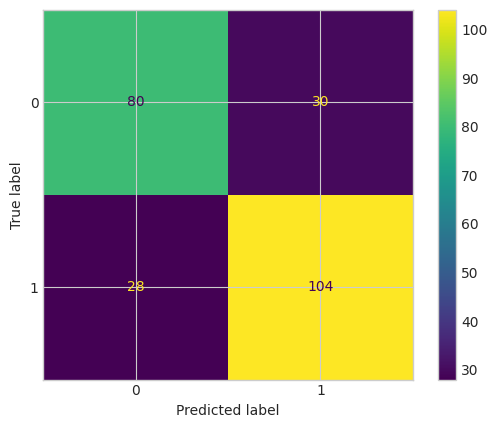

In [0]:
# TODO: Calcula y visualiza la matriz de confusión del modelo SGD.
cm = confusion_matrix(y_train, preds)  # comparo la prediccion con la realidad, en train
disp = ConfusionMatrixDisplay(confusion_matrix=cm)  # preparo el dibujo de la matriz
disp.plot()
plt.show()

# TODO: Interpreta TN, FP, FN y TP.
#TN(verdadero negativo): paciente sano, el modelo dice que esta sano. Bien.
#FP(falso positivo): paciente sano, pero el modelo dice que esta enfermo. Falsa alarma.
#FN(falso negativo): paciente enfermo, pero el modelo dice que esta sano. Se le escapa.
#TP(verdadero positivo): paciente enfermo, el modelo dice que esta enfermo. Bien.

# TODO: ¿Qué tipo de error es más grave en medicina?
# El falso negativo (FN) es el mas grave: le dice a un paciente enfermo que esta sano, y no recibe tratamiento a tiempo. El falso positivo (FP) tambien es malo, pero solo lleva a hacerle mas pruebas de mas a un paciente sano


In [0]:
# TODO: Calcula métricas del modelo SGD.
precision = precision_score(y_train, preds)  # de los que dije enfermos, cuantos lo eran de verdad
recall = recall_score(y_train, preds)  # de los enfermos reales, a cuantos pille
f1 = f1_score(y_train, preds)  # mezcla precision y recall en un solo numero
roc_auc = roc_auc_score(y_train, preds)

# TODO: Imprime e interpreta las métricas.
print(f"Precision: {precision} , Recall: {recall} , F1: {f1} , ROC-AUC: {roc_auc}")

# TODO: ¿Qué métrica es más importante en medicina y por qué?

#El recall es la mas importante: interesa mas pillar a todos los enfermos posibles, aunque eso lleve a alguna falsa alarma (menos precision), que dejarse enfermos sin detectar.


Precision: 0.7761194029850746 , Recall: 0.7878787878787878 , F1: 0.7819548872180451 , ROC-AUC: 0.7575757575757576


### 🌲 Modelo 2: Random Forest Classifier

**TODO: [Completa aquí] ¿Qué es Random Forest y por qué suele funcionar mejor que modelos simples?**

Random Forest es un modelo que en vez de usar un solo árbol de decisión, crea muchos árboles distintos (cientos, normalmente) y cada uno entrena con una parte distinta de los datos y mirando solo algunas columnas al azar en cada división. Para predecir, le pregunta a todos los árboles y se queda con lo que diga la mayoría (si más árboles dicen "enfermo" que "sano", predice "enfermo").

Suele funcionar mejor que un modelo simple porque un solo árbol se puede equivocar mucho si memoriza demasiado los datos de entrenamiento (overfitting), pero al combinar muchos árboles distintos, sus errores individuales tienden a cancelarse entre sí, y el resultado final es más estable y más preciso

Ahora probemos un modelo más potente y comparemos resultados.

In [0]:
# TODO: Entrena y evalúa un Random Forest en un nuevo run de MLflow.
with mlflow.start_run(run_name="Random Forest Classifier") as run:
    rf_clf = RandomForestClassifier(random_state=42)  # creo el modelo, mismo numero fijo que siempre

    rf_scores = cross_val_score(rf_clf, x_train_pr, y_train, cv=5)  # evaluo 5 veces, igual que con el SGD
    rf_preds = cross_val_predict(rf_clf, x_train_pr, y_train, cv=5)  # prediccion de cada paciente, para la matriz de confusion luego

    print("Scores:", rf_scores)
    print("Media:", rf_scores.mean())

    mlflow.log_metric("cv_accuracy_mean", rf_scores.mean())
# TODO: Explica qué hiperparámetros podrías ajustar y por qué comparas contra SGD.

#Podria ajustar n_estimators (cuantos arboles tiene el bosque) y max_depth (que tan profundo puede ser cada arbol)
# Comparo contra el SGD porque ese fue mi modelo baseline, con 0.76 de media. Si el Random Forest no supera eso, no merece la pena usar un modelo mas complicado.


2026/10/02 12:38:05 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


Scores: [0.71428571 0.7755102  0.83333333 0.91666667 0.85416667]
Media: 0.8187925170068027


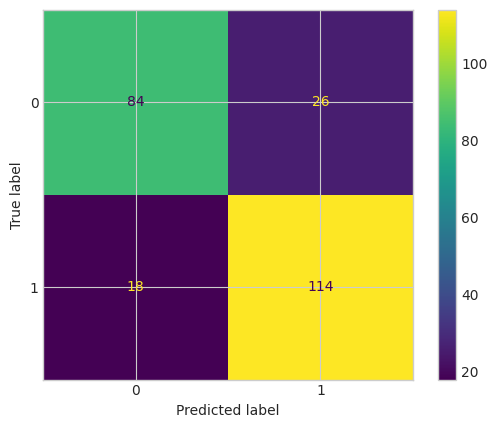

In [0]:
# TODO: Calcula y visualiza la matriz de confusión de Random Forest.
cm_rf = confusion_matrix(y_train, rf_preds)  # comparo prediccion con realidad, en train
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.show()

# TODO: Compara los errores con los del modelo SGD.

# SGD: TN=80, FP=30, FN=28, TP=104
# Random Forest: TN=84, FP=26, FN=18, TP=114
# El Random Forest mejora en los dos tipos de error: menos falsos positivos (26 vs 30) y,lo mas importante, menos falsos negativos (18 vs 28). Como el falso negativo es el error mas grave, el Random Forest es mejor


In [0]:
# TODO: Calcula métricas de Random Forest.
rf_precision = precision_score(y_train, rf_preds)   # de los que dije enfermos, cuantos lo eran de verdad
rf_recall = recall_score(y_train, rf_preds) # de los enfermos reales, a cuantos pille
rf_f1 = f1_score(y_train, rf_preds) # mezcla precision y recall en un solo numero
rf_roc_auc = roc_auc_score(y_train, rf_preds)   # mide cuanto separa el modelo sanos de enfermos (aqui con preds, no con probs)

# TODO: Crea una tabla comparativa SGD vs Random Forest.
comparativa = pd.DataFrame({
    "SGD": [precision, recall, f1, roc_auc],
    "Random Forest": [rf_precision, rf_recall, rf_f1, rf_roc_auc]
}, index=["Precision", "Recall", "F1", "ROC-AUC"])

print(comparativa)
# TODO: Decide qué modelo funciona mejor y justifica tu respuesta.

# Vemos que Random Forest funciona mejor, superando a SGD en las 4 métricas,(Precision 0.814 vs 0.776, Recall 0.864 vs 0.788, 
# F1 0.838 vs 0.782, ROC-AUC 0.814 vs 0.758).El recall es la métrica clave y ahí RF saca casi 8 puntos de ventaja,detectando más enfermos reales sin sacrificar precision.


                SGD  Random Forest
Precision  0.776119       0.814286
Recall     0.787879       0.863636
F1         0.781955       0.838235
ROC-AUC    0.757576       0.813636


## 🎯 Paso 9: Entrenamiento Final y Evaluación en Test

Ahora entrenaremos el modelo con **todo el conjunto de entrenamiento** y evaluaremos en el conjunto de prueba (que nunca ha visto).

In [0]:
# TODO: Entrena el modelo final usando todo el conjunto de entrenamiento procesado.
forest_clf = RandomForestClassifier(random_state=42)  # mismos parametros que el rf_clf de antes
forest_clf.fit(x_train_pr, y_train)  # entrena con TODO el train, no con cross-validation

# TODO: Explica por qué ahora entrenamos con todos los datos de train.

# Antes usabamos cross_val_score/cross_val_predict para evaluar el modelo sin gastar el test, dividiendo el train en 5 partes. Eso era solo para decidir que modelo era mejor (RF vs SGD).
#Ya que elegimos Random Forest, no necesitamos seguir reservando datos para validar: usamos el 100% del train disponible para que el modelo final aprenda de la mayor cantidad de datos posible antes de medirlo contra el test, que es el que de verdad simula datos nuevos.


2026/10/02 12:38:07 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 12:38:07 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f19f60707e5e4513ad14de204a1f9ce3', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/02 12:38:07 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 12:38:07 WARNING mlflow.sklearn: Failed to log training dataset information to MLflow Tracking. Reason: 'Series' object has no attribute 'flatten'
2026/10/02 12:38:07 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a Co

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [0]:
# TODO: Separa características y target del conjunto de prueba.
# x_test = ...
# y_test = ...

# TODO: Comprueba dimensiones.
print(X_test.shape, y_test.shape)


(61, 13) (61,)


In [0]:
# TODO: Transforma el conjunto de prueba y genera predicciones.
x_test_pr = full_pipeline.transform(X_test)  # aplico el pipeline ya entrenado, SIN volver a aprender nada
final_preds = forest_clf.predict(x_test_pr) # prediccion del modelo final sobre datos que nunca vio


# TODO: Explica por qué usamos transform() y no fit_transform() en test.

# Si usasemos fit_transform() en test, el pipeline volveria a calcular la mediana, la media y desviacion tipica a partir de los datos de test, en vez de usar las que aprendio del train.Eso seria "hacer trampa" porque el modelo estaria viendo informacion del test antes de evaluarlo, y ademas el test dejaria de ser una simulacion real de "datos nuevos nunca vistos".Con transform() aplicamos las mismas reglas (mediana, escalado, categorias) que ya aprendio
# del train


2026/10/02 12:38:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/10/02 12:38:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


Precision: 0.7894736842105263, Recall: 0.9090909090909091, F1: 0.8450704225352113, ROC-AUC: 0.8116883116883118, Accuracy: 0.819672131147541


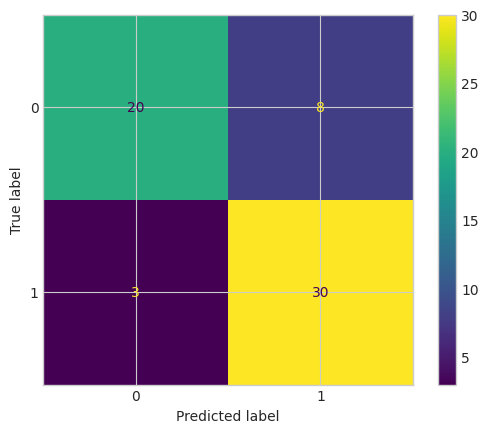

              precision    recall  f1-score   support

           0       0.87      0.71      0.78        28
           1       0.79      0.91      0.85        33

    accuracy                           0.82        61
   macro avg       0.83      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



In [0]:
# TODO: Evalúa resultados finales en el conjunto de prueba.
final_precision = precision_score(y_test, final_preds)   # de los que predije enfermos en test, cuantos lo eran
final_recall = recall_score(y_test, final_preds)   # de los enfermos reales en test, a cuantos pille
final_f1 = f1_score(y_test, final_preds)   # mezcla precision y recall
final_roc_auc = roc_auc_score(y_test, final_preds)   # separa sanos de enfermos (con preds, igual que antes)
final_accuracy = accuracy_score(y_test, final_preds)   # % total de aciertos

print(f"Precision: {final_precision}, Recall: {final_recall}, F1: {final_f1}, ROC-AUC: {final_roc_auc}, Accuracy: {final_accuracy}")

# TODO: Visualiza la matriz de confusión final.
cm_final = confusion_matrix(y_test, final_preds)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final)
disp_final.plot()
plt.show()

# TODO: Genera classification_report.
print(classification_report(y_test, final_preds))
# TODO: Interpreta si el modelo generaliza bien.

# Los resultados en test (Precision 0.789, Recall 0.909, F1 0.845, ROC-AUC 0.812, Accuracy 0.820) son muy parecidos a los que tenia en train (Precision 0.814, 
#Recall 0.864, F1 0.838, ROC-AUC 0.814), no hay ninguna caida fuerte de ninguna metrica al pasar de train a test. Si el modelo hubiese memorizado el train en vez de aprender patrones generales (overfitting), aqui se notaria un bajon claro en los resultados, y no es el caso.


## 🎉 Reflexión Final del Proyecto

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración de datos médicos reales
2. [ ] Pipeline de preprocesamiento
3. [ ] Entrenamiento y comparación de modelos
4. [ ] Evaluación con métricas de clasificación
5. [ ] Validación cruzada
6. [ ] Registro de experimentos en MLflow
7. [ ] Interpretación de resultados con matrices de confusión

### 📊 Conclusiones Clave

**TODO: Basándote en tus resultados, escribe tus conclusiones:**

1. **¿Qué modelo funcionó mejor?**
   - Random Forest. Le gana a SGD en las 4 métricas que comparé (precision, recall, f1 y roc-auc), y luego en test tambien se mantiene con buenos resultados.

2. **¿Por qué crees que funcionó mejor?**
   - Supongo que al ser un conjunto de arboles en vez de un solo modelo lineal, puede capturar relaciones mas complejas entre las variables que el SGD no pilla tan bien al ser mas simple.

3. **¿El modelo es suficientemente bueno para uso médico?**
   - Para un uso real yo diria que necesitariamos muchisimos datos para tener una buena fiabilidad, le falta mas validacion y mas datos antes de confiar en el de forma ciega.La decision final creo que la tendria que seguir tomando una persona siempre

4. **¿Qué métrica es más importante en este caso?**
   - El recall. Aqui interesa mas pillar a todos los enfermos posibles, aunque eso signifique algun falso positivo de mas, que dejarse a alguien enfermo sin detectar.

5. **¿Qué mejorarías del modelo?**
   - Probaria a ajustar hiperparametros como n_estimators o max_depth con un GridSearch, y tambien usaria mas datos si pudiera, porque con solo 303 pacientes el modelo tiene poco con lo que aprender.

---

### 💡 Reflexiones Importantes

#### ⚕️ Sobre Medicina e IA

**TODO: Reflexiona sobre:**

1. **Falsos Negativos vs Falsos Positivos**
   - En medicina, ¿cuál es más grave y por qué?
   - El falso negativo es mucho mas grave. Si el modelo dice que un enfermo esta sano, esa persona se va a casa sin tratamiento y la enfermedad puede avanzar sin que nadie se entere. Un falso positivo es molesto porque mandas a alguien sano a hacerse pruebas de mas, pero no pone en riesgo su vida como el otro caso.


2. **Responsabilidad Ética**
   - ¿Puede un modelo de IA tomar decisiones médicas solo?
   - No deberia. El modelo puede equivocarse (de hecho en mi test ya hay 3 falsos negativos) y encima no tiene en cuenta cosas que un medico si ve, como el historial completo del paciente o sintomas que no estan en estos datos. Deberia usarse como apoyo para el medico

3. **Interpretabilidad**
   - ¿Por qué es importante que los médicos entiendan cómo decide el modelo?
   - Porque si un medico no entiende por que el modelo predice lo que predice, no puede confiar en el ni detectar cuando se esta equivocando. Tambien le sirve para explicarselo al paciente, y para poder cuestionar el resultado si no coincide con lo que el ve clinicamente

---

### 🚀 Desafíos Adicionales

1. **Optimización de Hiperparámetros** con `GridSearchCV`.
2. **Prueba Otros Modelos** como Gradient Boosting, SVM o Logistic Regression.
3. **Feature Engineering** para crear o seleccionar características.
4. **Análisis de Errores** para entender pacientes mal clasificados.
5. **Curva ROC** para comparar thresholds y AUC.


In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del proyecto.

# ========================================
# TODO: DESAFÍO 1 - Grid Search
# ========================================
# from sklearn.model_selection import GridSearchCV
# param_grid = {...}
# grid_search = GridSearchCV(...)
# grid_search.fit(...)

# ========================================
# TODO: DESAFÍO 2 - Curva ROC
# ========================================
# from sklearn.metrics import roc_curve, auc
# y_proba = ...
# fpr, tpr, thresholds = roc_curve(...)
# TODO: visualiza la curva ROC.

# ========================================
# TODO: DESAFÍO 3 - Importancia de características
# ========================================
# feature_names = ...
# feature_importance = ...
# TODO: identifica e interpreta las características más importantes.

# ========================================
# TODO: DESAFÍO 4 - Comparar más modelos
# ========================================
# modelos = {...}
# resultados = []
# for nombre, modelo in modelos.items():
#     # Entrena, evalúa y registra cada modelo en MLflow
#     pass
